# Module 06: OpenCV for Computer Vision & Machine Learning
## Notebook 04: Edge Detection, Contour Analysis, and Shape Descriptors

Edges and contours represent structural boundaries where image brightness changes abruptly. In machine learning, contour properties form the basis of object shape descriptors, defect inspection, and dimension measurement pipelines.

---

### Learning Objectives
By the end of this notebook, you will be able to:
1. Compute directional spatial gradients using the **Sobel Operator** ($G_x, G_y$) and compute the **Laplacian Operator**.
2. Master the multi-stage **Canny Edge Detection** algorithm (Gaussian smoothing, gradient calculation, non-maximum suppression, hysteresis thresholding).
3. Extract and visualize topological contours using `cv2.findContours()` and `cv2.drawContours()`.
4. Calculate geometric properties: **Area**, **Perimeter**, **Moments**, **Centroids**, **Aspect Ratio**, and **Solidity**.
5. Compare upright bounding boxes (`cv2.boundingRect`) with minimum area rotated bounding boxes (`cv2.minAreaRect`).
6. **Advanced:** Classify geometric shapes automatically using the **Douglas-Peucker Polygon Approximation** algorithm (`cv2.approxPolyDP`).
7. **Advanced:** Construct a production **Automated Dimension Measurement & Inspection Pipeline** with oriented bounding boxes and orientation angles.

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

img_dir = "images" if os.path.exists("images") else "../images"
print(f"OpenCV Version: {cv2.__version__}")

OpenCV Version: 5.0.0


### 1. Image Gradients: Sobel & Laplacian Operators
Edges correspond to local maxima of the first derivative (gradient) or zero-crossings of the second derivative:
- **Sobel Operator (`cv2.Sobel`):** Computes first-order image derivatives:
  - Horizontal Gradient $G_x = \text{Sobel}(I, \text{dx}=1, \text{dy}=0)$
  - Vertical Gradient $G_y = \text{Sobel}(I, \text{dx}=0, \text{dy}=1)$
  - Gradient Magnitude: $G = \sqrt{G_x^2 + G_y^2}$
  - Gradient Direction: $\theta = \arctan(G_y / G_x)$
- **Laplacian Operator (`cv2.Laplacian`):** Computes second-order spatial derivatives $\nabla^2 I = \frac{\partial^2 I}{\partial x^2} + \frac{\partial^2 I}{\partial y^2}$.

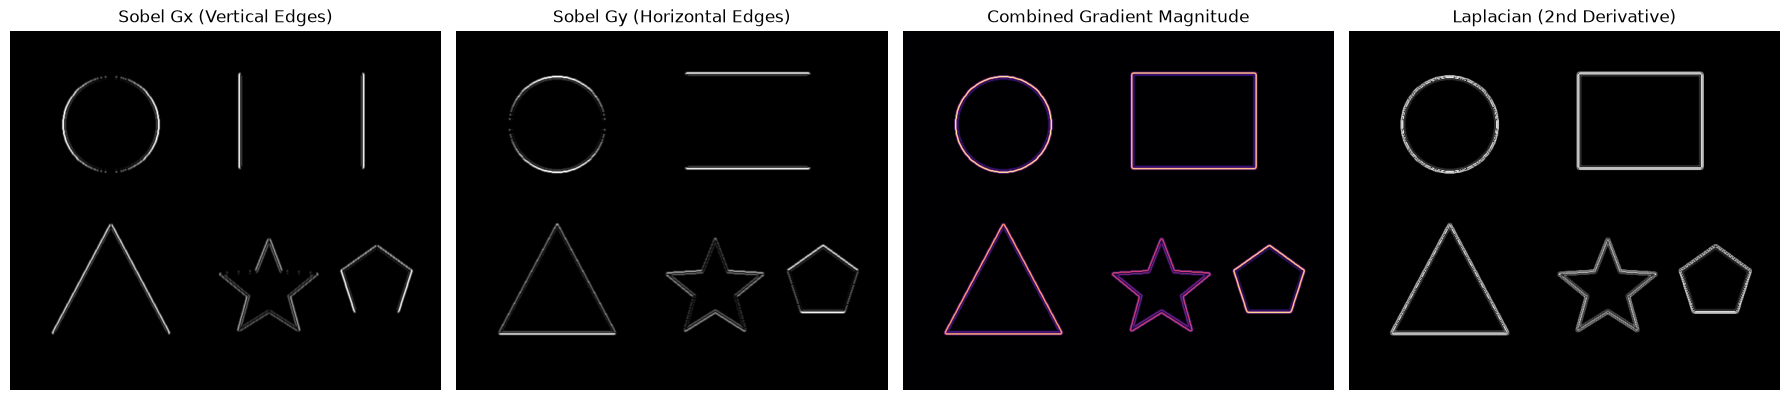

In [2]:
shapes_bgr = cv2.imread(os.path.join(img_dir, "shapes.png"))
shapes_gray = cv2.cvtColor(shapes_bgr, cv2.COLOR_BGR2GRAY)

# Pre-smooth with Gaussian filter to reduce high-frequency noise
blurred = cv2.GaussianBlur(shapes_gray, (3, 3), 0)

# 1. Sobel Gradients (using CV_64F to capture negative gradients)
sobel_x = cv2.Sobel(blurred, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(blurred, cv2.CV_64F, 0, 1, ksize=3)

# 2. Gradient Magnitude
grad_mag = np.hypot(sobel_x, sobel_y)
grad_mag = np.uint8(255 * grad_mag / np.max(grad_mag))

# 3. Laplacian
laplacian = cv2.Laplacian(blurred, cv2.CV_64F, ksize=3)
laplacian_abs = np.uint8(np.absolute(laplacian))

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))

axes[0].imshow(np.absolute(sobel_x), cmap="gray")
axes[0].set_title("Sobel Gx (Vertical Edges)")
axes[0].axis("off")

axes[1].imshow(np.absolute(sobel_y), cmap="gray")
axes[1].set_title("Sobel Gy (Horizontal Edges)")
axes[1].axis("off")

axes[2].imshow(grad_mag, cmap="magma")
axes[2].set_title("Combined Gradient Magnitude")
axes[2].axis("off")

axes[3].imshow(laplacian_abs, cmap="gray")
axes[3].set_title("Laplacian (2nd Derivative)")
axes[3].axis("off")

plt.tight_layout()
plt.show()

### 2. Canny Edge Detection
John F. Canny developed the optimal edge detection algorithm consisting of 4 distinct stages:
1. **Gaussian Filter:** Smooths image to suppress noise.
2. **Gradient Intensity:** Calculates $G$ and orientation $\theta$ via Sobel operators.
3. **Non-Maximum Suppression (NMS):** Thins edges to 1-pixel width by suppressing pixels that are not local maxima along the gradient direction.
4. **Hysteresis Thresholding:** Uses two thresholds ($T_{\text{lower}}, T_{\text{upper}}$):
   - Pixels with gradient $> T_{\text{upper}}$ are **sure edges**.
   - Pixels with gradient $< T_{\text{lower}}$ are **discarded**.
   - Pixels in-between are retained **only if connected to a sure edge**.

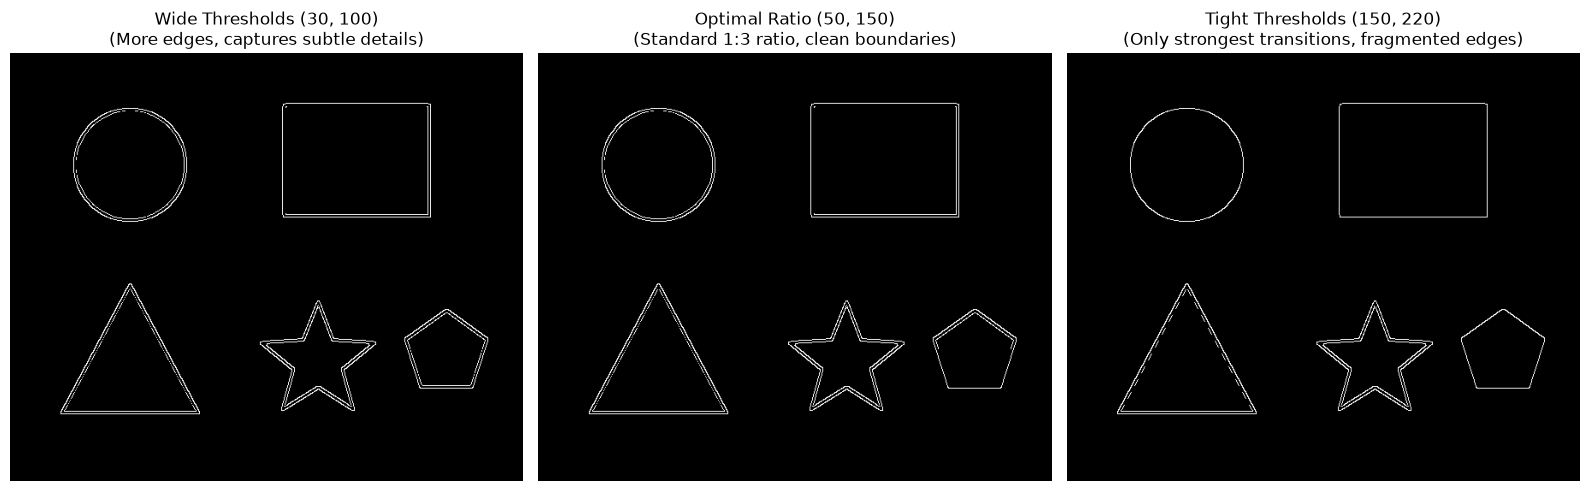

In [3]:
# Experimenting with hysteresis threshold ratios
canny_wide = cv2.Canny(blurred, threshold1=30, threshold2=100)
canny_tight = cv2.Canny(blurred, threshold1=150, threshold2=220)
canny_optimal = cv2.Canny(blurred, threshold1=50, threshold2=150)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(canny_wide, cmap="gray")
axes[0].set_title("Wide Thresholds (30, 100)\n(More edges, captures subtle details)")
axes[0].axis("off")

axes[1].imshow(canny_optimal, cmap="gray")
axes[1].set_title("Optimal Ratio (50, 150)\n(Standard 1:3 ratio, clean boundaries)")
axes[1].axis("off")

axes[2].imshow(canny_tight, cmap="gray")
axes[2].set_title("Tight Thresholds (150, 220)\n(Only strongest transitions, fragmented edges)")
axes[2].axis("off")

plt.tight_layout()
plt.show()

### 3. Finding & Drawing Contours
A contour is a continuous curve joining all boundary points having the same color or intensity:
- `cv2.findContours(image, mode, method)`:
  - **`mode`:** `cv2.RETR_EXTERNAL` (only outermost boundaries), `cv2.RETR_TREE` (full hierarchical tree of parents/children).
  - **`method`:** `cv2.CHAIN_APPROX_SIMPLE` (compresses horizontal/vertical segments into endpoints, saving memory) vs. `cv2.CHAIN_APPROX_NONE` (all points).
- `cv2.drawContours(image, contours, contourIdx, color, thickness)`: `contourIdx=-1` draws all contours.

Total contours detected: 5


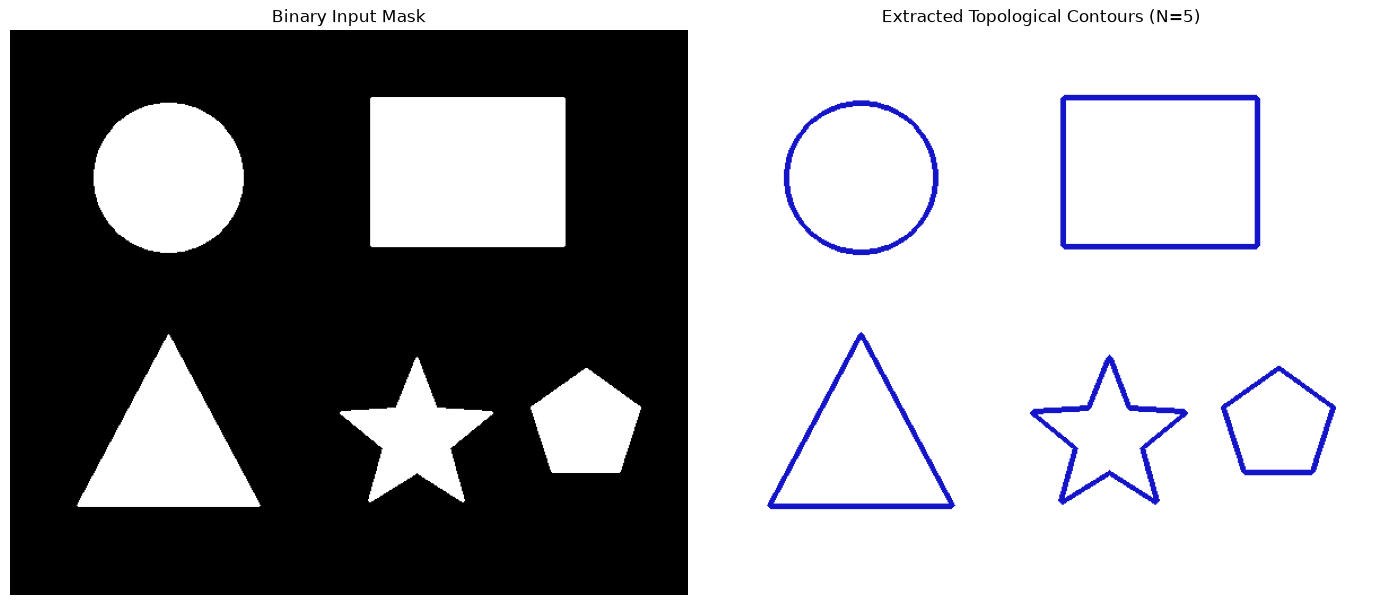

In [4]:
# Binarize shapes image
_, thresh = cv2.threshold(shapes_gray, 240, 255, cv2.THRESH_BINARY_INV)

# Find external contours
contours, hierarchy = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
print(f"Total contours detected: {len(contours)}")

# Draw all contours on a blank canvas
contour_canvas = np.full_like(shapes_bgr, 255)
cv2.drawContours(contour_canvas, contours, -1, (200, 20, 20), thickness=3)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(thresh, cmap="gray")
axes[0].set_title("Binary Input Mask")
axes[0].axis("off")

axes[1].imshow(cv2.cvtColor(contour_canvas, cv2.COLOR_BGR2RGB))
axes[1].set_title(f"Extracted Topological Contours (N={len(contours)})")
axes[1].axis("off")

plt.tight_layout()
plt.show()

### 4. Geometric Properties, Moments & Centroids
OpenCV provides rich geometric analysis functions for every contour:
- **Area:** $A = \text{cv2.contourArea}(C)$
- **Arc Length (Perimeter):** $P = \text{cv2.arcLength}(C, \text{closed=True})$
- **Spatial Moments:** $M_{pq} = \sum_x \sum_y x^p y^q I(x, y)$ computed via `cv2.moments(C)`.
  - **Centroid:** $\bar{x} = \frac{M_{10}}{M_{00}}, \quad \bar{y} = \frac{M_{01}}{M_{00}}$
- **Bounding Boxes:**
  - Upright axis-aligned: `x, y, w, h = cv2.boundingRect(C)`
  - Rotated Minimum Area: `rect = cv2.minAreaRect(C)` returns `((center_x, center_y), (width, height), angle)`.

In [5]:
# Inspect and analyze each detected shape
print("--- CONTOUR GEOMETRIC PROFILES ---")
for i, c in enumerate(contours):
    area = cv2.contourArea(c)
    perimeter = cv2.arcLength(c, closed=True)
    M = cv2.moments(c)
    if M["m00"] > 0:
        cx = int(M["m10"] / M["m00"])
        cy = int(M["m01"] / M["m00"])
    else:
        cx, cy = 0, 0
    print(f"Shape #{i + 1}: Area = {area:.1f} px², Perimeter = {perimeter:.1f} px, Centroid = ({cx}, {cy})")

--- CONTOUR GEOMETRIC PROFILES ---
Shape #1: Area = 6240.0 px², Perimeter = 315.9 px, Centroid = (509, 349)
Shape #2: Area = 6715.5 px², Perimeter = 520.5 px, Centroid = (359, 359)
Shape #3: Area = 12422.0 px², Perimeter = 531.9 px, Centroid = (140, 370)
Shape #4: Area = 13700.0 px², Perimeter = 439.0 px, Centroid = (140, 129)
Shape #5: Area = 22702.0 px², Perimeter = 605.7 px, Centroid = (405, 125)


### 5. Complex Application 1: Douglas-Peucker Polygon Approximation
The **Douglas-Peucker algorithm (`cv2.approxPolyDP`)** simplifies a polyline by iteratively removing vertices closer than an epsilon distance threshold:
$$\epsilon = \alpha \times \text{arcLength}(C)$$
By examining the number of vertices in the approximated polygon, we can classify shapes automatically:
- 3 vertices $\to$ **Triangle**
- 4 vertices $\to$ **Quadrilateral / Rectangle**
- 5 vertices $\to$ **Pentagon**
- 10 vertices (alternating radii) $\to$ **Star**
- $> 8$ smooth vertices with high circularity ($\frac{4\pi A}{P^2} \approx 1$) $\to$ **Circle**

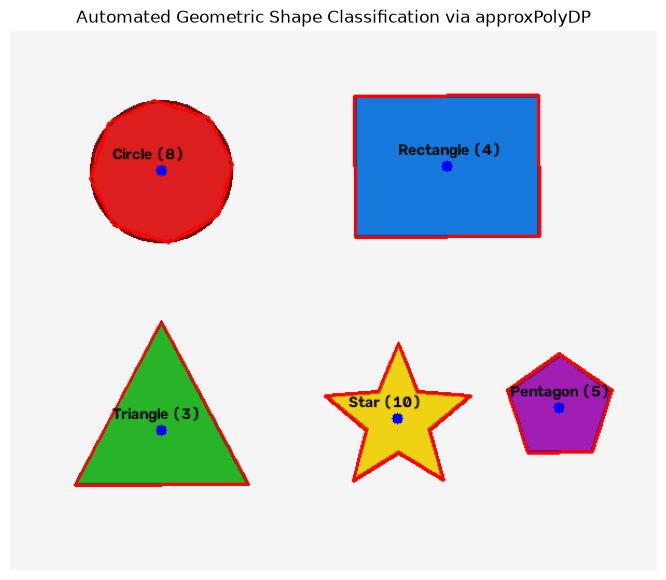

In [6]:
classified_img = shapes_bgr.copy()

for c in contours:
    # Filter out tiny noise contours
    if cv2.contourArea(c) < 500:
        continue

    # Approximate polygon
    peri = cv2.arcLength(c, True)
    approx = cv2.approxPolyDP(c, epsilon=0.03 * peri, closed=True)
    num_vertices = len(approx)

    # Compute centroid for text label
    M = cv2.moments(c)
    cx = int(M["m10"] / M["m00"]) if M["m00"] > 0 else 0
    cy = int(M["m01"] / M["m00"]) if M["m00"] > 0 else 0

    # Classify based on vertex count
    if num_vertices == 3:
        label = "Triangle (3)"
    elif num_vertices == 4:
        label = "Rectangle (4)"
    elif num_vertices == 5:
        label = "Pentagon (5)"
    elif num_vertices == 10:
        label = "Star (10)"
    else:
        label = f"Circle ({num_vertices})"

    # Draw approximated polygon and classification text
    cv2.drawContours(classified_img, [approx], -1, (0, 0, 255), 2)
    cv2.circle(classified_img, (cx, cy), 5, (255, 0, 0), -1)
    cv2.putText(classified_img, label, (cx - 45, cy - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.48, (10, 10, 10), 2, cv2.LINE_AA)

plt.figure(figsize=(9, 7))
plt.imshow(cv2.cvtColor(classified_img, cv2.COLOR_BGR2RGB))
plt.title("Automated Geometric Shape Classification via approxPolyDP")
plt.axis("off")
plt.show()

### 6. Complex Application 2: Production Dimension Measurement & Inspection Pipeline
In industrial visual quality control (e.g. PCB inspection, conveyor belt sorting), parts can appear at arbitrary angles. An axis-aligned bounding box exaggerates object dimensions; instead, we compute the **Rotated Minimum Area Bounding Box (`cv2.minAreaRect`)**:
1. `minAreaRect` returns the exact oriented rectangle: center $(c_x, c_y)$, size $(w, h)$, and rotation angle $\theta$.
2. `cv2.boxPoints(rect)` recovers the 4 oriented corners in pixel space.
3. Draw oriented bounding box and overlay measured dimensions (width, height, orientation angle).

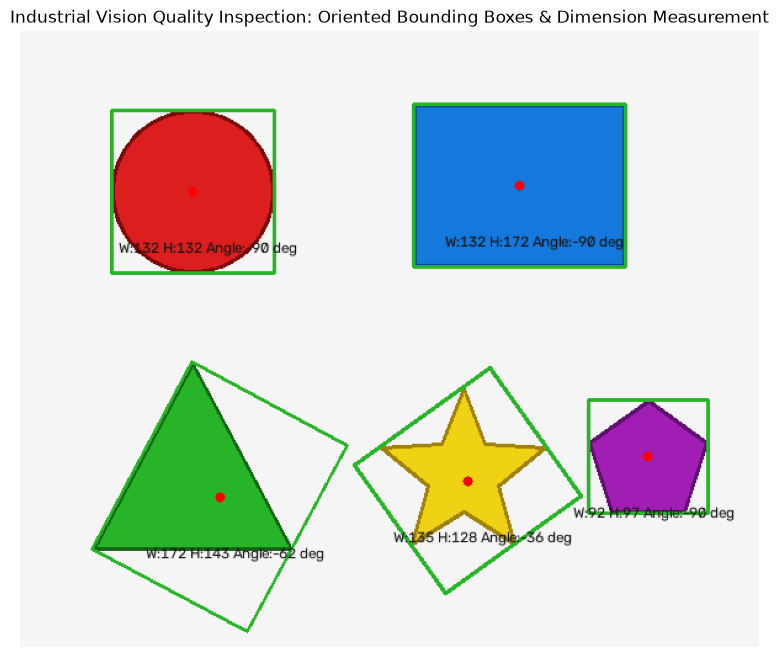

In [7]:
inspection_img = shapes_bgr.copy()

for i, c in enumerate(contours):
    if cv2.contourArea(c) < 500:
        continue

    # 1. Compute rotated minimum area bounding rectangle
    rect = cv2.minAreaRect(c)
    (cx, cy), (width, height), angle = rect

    # 2. Get the 4 oriented vertex coordinates
    box = cv2.boxPoints(rect)
    box = np.int32(box)

    # 3. Draw rotated green bounding box
    cv2.drawContours(inspection_img, [box], 0, (40, 180, 40), 2)

    # 4. Draw center point
    cv2.circle(inspection_img, (int(cx), int(cy)), 4, (0, 0, 255), -1)

    # 5. Overlay measurement badge
    dim_text = f"W:{width:.0f} H:{height:.0f} Angle:{angle:.0f} deg"
    cv2.putText(inspection_img, dim_text, (int(cx) - 60, int(cy) + 50),
                cv2.FONT_HERSHEY_SIMPLEX, 0.42, (20, 20, 20), 1, cv2.LINE_AA)

plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(inspection_img, cv2.COLOR_BGR2RGB))
plt.title("Industrial Vision Quality Inspection: Oriented Bounding Boxes & Dimension Measurement")
plt.axis("off")
plt.show()